In [1]:
import segment 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap

In [2]:
import torch
import torch.nn as nn 
import torch.nn.functional as F 
from torchvision import models 

### Loading the 3D data

In [3]:
image, image_array = segment.read_img()
image.shape, image_array

((216, 512, 512),
 <SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'itk::simple::Image *' at 0x70a2ec695350> >)

In [4]:
segmented_bone_mask = segment.get_segmented_bone(image)
segmented_bone_mask.shape

clipped
normalized
noise reduction filters to each slice


(216, 512, 512)

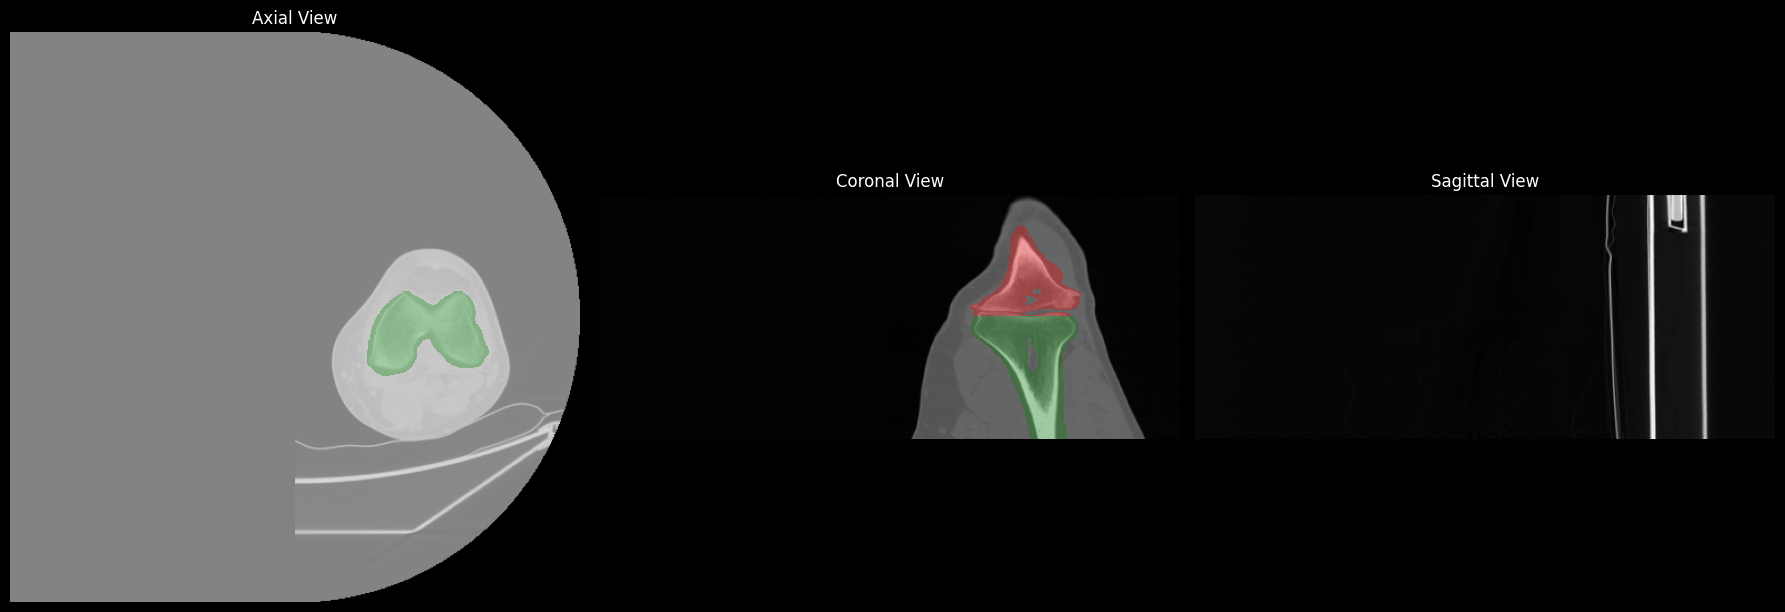

In [5]:
axial_index = image.shape[0] // 2      
coronal_index = image.shape[1] // 2    
sagittal_index = image.shape[2] // 2   

custom_cmap = ListedColormap(['none', 'red', 'green'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='black')

# Axial
axes[0].imshow(image[axial_index, :, :], cmap='gray')
axes[0].imshow(segmented_bone_mask[axial_index, :, :], cmap=custom_cmap, alpha=0.33, interpolation='none')
axes[0].set_title('Axial View', color='white')

# Coronal
axes[1].imshow(image[:, coronal_index, :], cmap='gray')
axes[1].imshow(segmented_bone_mask[:, coronal_index, :], cmap=custom_cmap, alpha=0.33, interpolation='none')
axes[1].set_title('Coronal View', color='white')

# Sagittal
axes[2].imshow(image[:, :, sagittal_index], cmap='gray')
axes[2].imshow(segmented_bone_mask[:, :, sagittal_index], cmap=custom_cmap, alpha=0.33, interpolation='none')
axes[2].set_title('Sagittal View', color='white')

for ax in axes:
    ax.axis('off')
    ax.set_facecolor('black')

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from scipy.spatial.distance import cosine
import pandas as pd

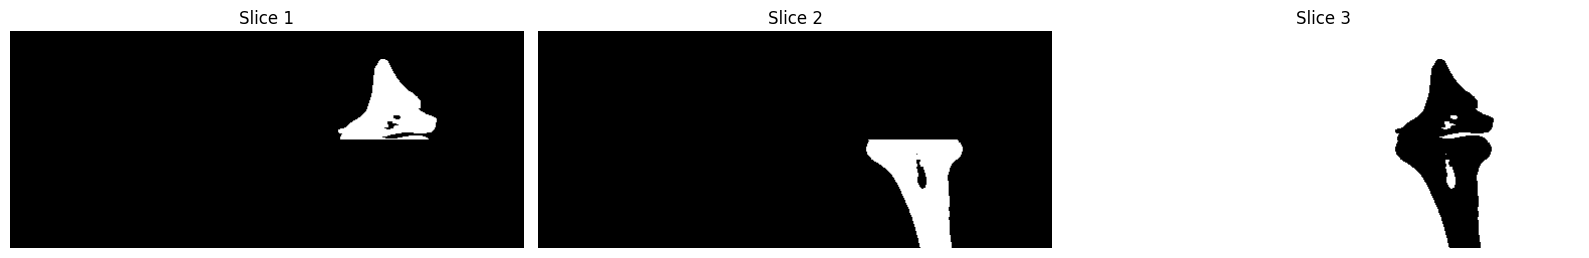

In [7]:
femur_mask = (segmented_bone_mask == 1).astype(np.float32)
tibia_mask = (segmented_bone_mask == 2).astype(np.float32)
background_mask = (segmented_bone_mask == 0).astype(np.float32)
# plt.imshow(femur_mask[:, coronal_index, :])


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 10))

# Display each image
ax1.imshow(femur_mask[:, coronal_index, :], cmap='gray')
ax1.set_title('Slice 1')
ax1.axis('off')

ax2.imshow(tibia_mask[:, coronal_index, :], cmap='gray')
ax2.set_title('Slice 2')
ax2.axis('off')

ax3.imshow(background_mask[:, coronal_index, :], cmap='gray')
ax3.set_title('Slice 3')
ax3.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

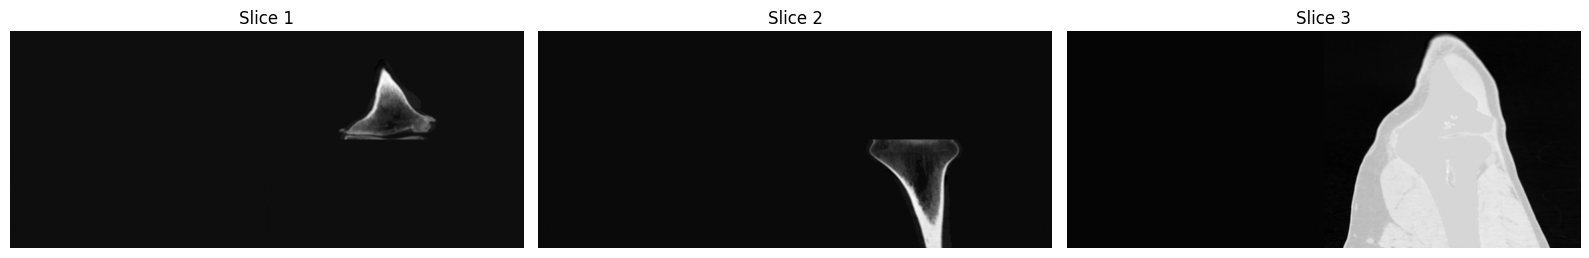

In [8]:
femur_region = image * femur_mask
tibia_region = image * tibia_mask
background_region = image * background_mask


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 10))

# Display each image
ax1.imshow(femur_region[:, coronal_index, :], cmap='gray')
ax1.set_title('Slice 1')
ax1.axis('off')

ax2.imshow(tibia_region[:, coronal_index, :], cmap='gray')
ax2.set_title('Slice 2')
ax2.axis('off')

ax3.imshow(background_region[:, coronal_index, :], cmap='gray')
ax3.set_title('Slice 3')
ax3.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

### Model Handling, Pytorch

In [ ]:
import torch.nn as nn
import torchvision.models as models

def inflate_conv(conv2d, time_dim=3):
    """Takes a 2D convolution, converts into a 3D convolution."""
    conv3d = nn.Conv3d(
        conv2d.in_channels, conv2d.out_channels,
        kernel_size=(time_dim, *conv2d.kernel_size),
        stride=(1, *conv2d.stride),
        padding=(time_dim // 2, *conv2d.padding),
        bias=(conv2d.bias is not None)
    )
    with torch.no_grad():
        # adds depth dimension
        w2d = conv2d.weight.data.unsqueeze(2)  
        # normalize weights
        w3d = w2d.repeat(1, 1, time_dim, 1, 1) / time_dim  
        conv3d.weight.copy_(w3d)
        if conv2d.bias is not None:
            conv3d.bias.copy_(conv2d.bias.data)
    return conv3d

def inflate_bn(bn2d):
    """Inflating 2D batch normalization to 3D"""
    bn3d = nn.BatchNorm3d(bn2d.num_features)

    # parameters are directly copied 
    bn3d.load_state_dict(bn2d.state_dict())
    return bn3d

def inflate_pool(pool2d, pool_type):
    """Inflate pooling layer from 2D to 3D"""
    kernel_size = pool2d.kernel_size if isinstance(pool2d.kernel_size, tuple) else (pool2d.kernel_size, pool2d.kernel_size)
    stride = pool2d.stride if pool2d.stride is not None else kernel_size
    stride = stride if isinstance(stride, tuple) else (stride, stride)
    padding = pool2d.padding if isinstance(pool2d.padding, tuple) else (pool2d.padding, pool2d.padding)
    
    kernel3d = (1, *kernel_size)
    stride3d = (1, *stride)
    padding3d = (0, *padding)

    if pool_type == 'max':
        # flags are preserved as to 2D pooling layers
        return nn.MaxPool3d(kernel_size=kernel3d, stride=stride3d, padding=padding3d, ceil_mode=pool2d.ceil_mode)
    elif pool_type == 'avg':
        return nn.AvgPool3d(kernel_size=kernel3d, stride=stride3d, padding=padding3d, ceil_mode=pool2d.ceil_mode,
                            count_include_pad=pool2d.count_include_pad, divisor_override=pool2d.divisor_override)
    else:
        raise ValueError('Unknown pool type')

def inflate_adaptive_avg_pool(pool2d):
    output_size = pool2d.output_size
    if isinstance(output_size, int):
        output_size = (1, output_size, output_size)
    elif len(output_size) == 2:
        output_size = (1, *output_size)
    return nn.AdaptiveAvgPool3d(output_size)

# recursively goes through all submodules
def inflate_module(module):
    for name, child in module.named_children():
        if isinstance(child, nn.Conv2d):
            setattr(module, name, inflate_conv(child))
        elif isinstance(child, nn.BatchNorm2d):
            setattr(module, name, inflate_bn(child))
        elif isinstance(child, nn.MaxPool2d):
            setattr(module, name, inflate_pool(child, 'max'))
        elif isinstance(child, nn.AvgPool2d):
            setattr(module, name, inflate_pool(child, 'avg'))
        elif isinstance(child, nn.AdaptiveAvgPool2d):
            setattr(module, name, inflate_adaptive_avg_pool(child))
        else:
            # calling itself in the child module 
            inflate_module(child)
    return module


model2d = models.densenet121(pretrained=True)
model3d = inflate_module(model2d)


def forward_3d(self, x):
    # new forward method to handle 3D data
    features = self.features(x)
    out = F.adaptive_avg_pool3d(features, (1,1,1))
    out = torch.flatten(out, 1)
    out = self.classifier(out)
    return out

# allowing 2D trained model to handle 3D datasets
model3d.forward = forward_3d.__get__(model3d, model3d.__class__)
model3d


/home/fm-pc-lt-308/Desktop/env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/fm-pc-lt-308/Desktop/env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DenseNet(
  (features): Sequential(
    (conv0): Conv3d(3, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
    (norm0): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1), dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv3d(64, 128, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0), bias=False)
        (norm2): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv3d(128, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm3d(96, eps=1e-05,

### Try of inference

In [11]:
conv_layers = []

for name, module in model3d.named_modules():
    if isinstance(module, nn.Conv3d):
        conv_layers.append((name, module))

# Print last 10 conv layer names
for name, _ in conv_layers[-10:]:
    print(name)

features.denseblock4.denselayer12.conv1
features.denseblock4.denselayer12.conv2
features.denseblock4.denselayer13.conv1
features.denseblock4.denselayer13.conv2
features.denseblock4.denselayer14.conv1
features.denseblock4.denselayer14.conv2
features.denseblock4.denselayer15.conv1
features.denseblock4.denselayer15.conv2
features.denseblock4.denselayer16.conv1
features.denseblock4.denselayer16.conv2


In [12]:
target_layers = [
    "features.denseblock4.denselayer16.conv2",
    "features.denseblock4.denselayer15.conv2",
    "features.denseblock4.denselayer14.conv2",
]


In [13]:
features = {}

def get_hook(name):
    print(name)
    def hook(module, input, output):
        features[name] = output
    return hook

for name, module in model3d.named_modules():
    if name in target_layers:
        module.register_forward_hook(get_hook(name))


features.denseblock4.denselayer14.conv2
features.denseblock4.denselayer15.conv2
features.denseblock4.denselayer16.conv2


In [23]:
temp = torch.randn(216, 512, 512)

print("Initial temp shape:", temp.shape)  # Should be (216, 512, 512)

temp = temp.unsqueeze(-1).repeat(1, 1, 1, 3)  # Shape: (216, 512, 512, 3)
print("After channel replication:", temp.shape)

temp = temp.permute(3, 0, 1, 2)  # Shape: (3, 216, 512, 512)
print("After permute:", temp.shape)

# adding batch dimension
temp = temp.unsqueeze(0)  # Shape: (1, 3, 216, 512, 512)
print("After adding batch dim:", temp.shape)

# resize
target_size = 216
temp = F.interpolate(
    temp,
    size=(target_size, target_size, target_size),
    mode='trilinear',
    align_corners=False
)  # Shape: (1, 3, 216, 216, 216)
print("After interpolation:", temp.shape)

temp = temp.squeeze(0).permute(1, 2, 3, 0)  # Shape: (216, 216, 216, 3)
print("Final shape before batch:", temp.shape)

# Step 6: Add batch dimension for model input
temp = temp.permute(3, 0, 1, 2).unsqueeze(0)  # Shape: (1, 3, 216, 216, 216)
print("Final model input shape:", temp.shape)


# with torch.no_grad():
#     _ = model3d(temp)

Initial temp shape: torch.Size([216, 512, 512])
After channel replication: torch.Size([216, 512, 512, 3])
After permute: torch.Size([3, 216, 512, 512])
After adding batch dim: torch.Size([1, 3, 216, 512, 512])
After interpolation: torch.Size([1, 3, 216, 216, 216])
Final shape before batch: torch.Size([216, 216, 216, 3])
Final model input shape: torch.Size([1, 3, 216, 216, 216])


In [17]:
features.keys()

dict_keys(['features.denseblock4.denselayer14.conv2', 'features.denseblock4.denselayer15.conv2', 'features.denseblock4.denselayer16.conv2'])

In [18]:
feat_last = features["features.denseblock4.denselayer16.conv2"]
feat_3rd = features["features.denseblock4.denselayer15.conv2"]
feat_5th = features["features.denseblock4.denselayer14.conv2"]

In [19]:
feat_last.shape, feat_3rd.shape, feat_5th.shape

(torch.Size([1, 32, 216, 4, 4]),
 torch.Size([1, 32, 216, 4, 4]),
 torch.Size([1, 32, 216, 4, 4]))

In [20]:
gap = lambda x: F.adaptive_avg_pool3d(x, (1,1,1)).squeeze()

f1 = gap(feat_last)
f2 = gap(feat_3rd)
f3 = gap(feat_5th)
f1.shape, f2.shape, f3.shape

(torch.Size([32]), torch.Size([32]), torch.Size([32]))

### Function

In [ ]:
model3d.eval()

target_layers = [
    "features.denseblock4.denselayer16.conv2",
    "features.denseblock4.denselayer15.conv2",
    "features.denseblock4.denselayer14.conv2",
]

features = {}

def get_hook(name):
    def hook(module, input, output):
        features[name] = output
    return hook

# Register hooks for the 3 target layers
for name, module in model3d.named_modules():
    if name in target_layers:
        module.register_forward_hook(get_hook(name))


def preprocess_region(region_tensor):
    temp = region_tensor.unsqueeze(-1).repeat(1, 1, 1, 3)  # (216, 512, 512, 3)
    temp = temp.permute(3, 0, 1, 2)  # (3, 216, 512, 512)
    temp = temp.unsqueeze(0)  # (1, 3, 216, 512, 512)

    # converting 512 pixel size to 216 for faster computation
    temp = F.interpolate(temp, size=(216, 216, 216), mode='trilinear', align_corners=False)
    return temp  # (1, 3, 216, 216, 216)


def extract_features(region_tensor):
    # need new features for different regions, with full clearance of memory of features in required conv layers
    features.clear()  # reset hooks output
    inp = preprocess_region(region_tensor)
    with torch.no_grad():
        _ = model3d(inp)

    gap = lambda x: F.adaptive_avg_pool3d(x, (1,1,1)).squeeze()
    feat_last = gap(features["features.denseblock4.denselayer16.conv2"])
    feat_3rd = gap(features["features.denseblock4.denselayer15.conv2"])
    feat_5th = gap(features["features.denseblock4.denselayer14.conv2"])

    return {
        'last': feat_last,
        'third_last': feat_3rd,
        'fifth_last': feat_5th
    }


def compare_regions(feat_a, feat_b):
    return {
        'last': F.cosine_similarity(feat_a['last'].unsqueeze(0), feat_b['last'].unsqueeze(0)).item(),
        'third_last': F.cosine_similarity(feat_a['third_last'].unsqueeze(0), feat_b['third_last'].unsqueeze(0)).item(),
        'fifth_last': F.cosine_similarity(feat_a['fifth_last'].unsqueeze(0), feat_b['fifth_last'].unsqueeze(0)).item()
    }


In [11]:
tibia_region.shape, femur_region.shape, background_region.shape

((216, 512, 512), (216, 512, 512), (216, 512, 512))

In [12]:
# tibia = torch.tensor(tibia_region)
# femur = torch.tensor(femur_region)
# background = torch.tensor(background_region)

tibia = torch.tensor(tibia_region, dtype=torch.float)
femur = torch.tensor(femur_region, dtype=torch.float)
background = torch.tensor(background_region, dtype=torch.float)

# Extract features
features_dict = {
    'tibia': extract_features(tibia),
    'femur': extract_features(femur),
    'background': extract_features(background)
}


In [13]:
# Compute cosine similarities
results = []

pairs = [
    ('tibia', 'femur'),
    ('tibia', 'background'),
    ('femur', 'background')
]

for a, b in pairs:
    sim = compare_regions(features_dict[a], features_dict[b])
    row = {
        'pair': f'{a}↔{b}',
        'last': sim['last'],
        'third_last': sim['third_last'],
        'fifth_last': sim['fifth_last']
    }
    results.append(row)


In [14]:
import pandas as pd 

results_df = pd.DataFrame(results)
results_df

,pair,last,third_last,fifth_last
0,tibia↔femur,0.882862,0.974867,0.866306
1,tibia↔background,0.205657,0.684762,0.160198
2,femur↔background,0.328276,0.653026,0.020768


In [15]:
results_df.to_csv("results.csv", index=False)

### Analysing the features, for further conclusive evidences of the feature maps

In [ ]:
for region in ["tibia", "femur", "background"]:
    for layer in ["last", "third_last", "fifth_last"]:
        norm = features_dict[region][layer].norm().item()
        print(f"{region:<12} {layer:<12} norm = {norm:.4f}")

tibia        last         norm = 0.4247
tibia        third_last   norm = 0.7982
tibia        fifth_last   norm = 0.2218
femur        last         norm = 0.3536
femur        third_last   norm = 1.1171
femur        fifth_last   norm = 0.2699
background   last         norm = 6.8644
background   third_last   norm = 6.7134
background   fifth_last   norm = 1.7444


### Comparatively, tibia and femur have lower norms, as their spatial regions are smaller. In contrast, background has higher norm, since it has large spatial area.

In [ ]:
from itertools import combinations

def diff_stats(fa, fb):
    diff = (fa - fb).abs()
    return {
        'max': diff.max().item(),
        'mean': diff.mean().item(),
        'std': diff.std().item()
    }

for layer in ["last", "third_last", "fifth_last"]:
    print(f"\nLayer: {layer}")
    for a, b in combinations(["tibia", "femur", "background"], 2):
        stats = diff_stats(features_dict[a][layer], features_dict[b][layer])
        print(f"{a} ↔ {b}: mean={stats['mean']:.4f}, std={stats['std']:.4f}, max={stats['max']:.4f}")



Layer: last
tibia ↔ femur: mean=0.0290, std=0.0208, max=0.0841
tibia ↔ background: mean=0.8799, std=0.8294, max=3.0546
femur ↔ background: mean=0.8809, std=0.8195, max=3.0363

Layer: third_last
tibia ↔ femur: mean=0.0463, std=0.0501, max=0.2321
tibia ↔ background: mean=0.5788, std=0.9444, max=4.9769
femur ↔ background: mean=0.5718, std=0.9169, max=4.8705

Layer: fifth_last
tibia ↔ femur: mean=0.0187, std=0.0151, max=0.0683
tibia ↔ background: mean=0.2352, std=0.1966, max=0.8349
femur ↔ background: mean=0.2375, std=0.2041, max=0.8585


### Femur and Tibia are almost numerically identical vectors, so less std, but bones with background have higher std. 

In [ ]:
def normalized_cosine(a, b):
    a_n = F.normalize(a, dim=0)
    b_n = F.normalize(b, dim=0)
    return F.cosine_similarity(a_n.unsqueeze(0), b_n.unsqueeze(0)).item()

print("\nNormalized Cosine Similarities:")
for a, b in pairs:
    sim = {
        layer: normalized_cosine(features_dict[a][layer], features_dict[b][layer])
        for layer in ["last", "third_last", "fifth_last"]
    }
    print(f"{a} ↔ {b}: {sim}")



Normalized Cosine Similarities:
tibia ↔ femur: {'last': 0.8828617930412292, 'third_last': 0.9748666286468506, 'fifth_last': 0.8663060069084167}
tibia ↔ background: {'last': 0.20565678179264069, 'third_last': 0.6847617626190186, 'fifth_last': 0.16019798815250397}
femur ↔ background: {'last': 0.3282759487628937, 'third_last': 0.6530256271362305, 'fifth_last': 0.02076764404773712}


### Normalized cosine similarity is similar for bones, and less for bone with background.